In [1]:
import tensorflow as tf
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import SGD, Adam


I0000 00:00:1781576426.358231  133202 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781576426.425833  133202 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781576428.175508  133202 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
print(tf.__version__)

2.21.0


In [4]:
try:
    loaded_data = np.loadtxt('./diabetes.csv', delimiter=',')
    seperation_rate = 0.3  #분리 비율
    test_data_num = int(len(loaded_data) * seperation_rate)
    print(test_data_num)
    np.random.shuffle(loaded_data)

    test_data = loaded_data[0:test_data_num]
    train_data = loaded_data[test_data_num:]

    train_x_data = train_data[:, 0:-1]
    train_t_data = train_data[:,[-1]]

    test_x_data = test_data[:, 0:-1]
    test_t_data = test_data[:,[-1]]

    print("loaded_data.shape = ", loaded_data.shape)
    print("training_x_data.shape = ", train_x_data.shape)
    print("training_t_data.shape = ", train_t_data.shape)

    print("test_x_data.shape = ", test_x_data.shape)
    print("test_t_data.shape = ", test_t_data.shape)

except Exception as err:
    print(str(err))

227
loaded_data.shape =  (759, 9)
training_x_data.shape =  (532, 8)
training_t_data.shape =  (532, 1)
test_x_data.shape =  (227, 8)
test_t_data.shape =  (227, 1)


In [5]:
model = Sequential()

In [6]:
model.add(Dense(train_t_data.shape[1],input_shape=(train_x_data.shape[1],),activation='sigmoid'))

/home/work/git/TensorflowPjt/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1781577075.965235  133202 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [7]:
model.compile(optimizer=SGD(learning_rate=0.01),
              loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
from datetime import datetime
start_time = datetime.now()
hist = model.fit(train_x_data, train_t_data, epochs=1000, validation_split=0.2, verbose=2)
end_time = datetime.now()
print('\n Elapsed Time=> ', end_time - start_time)

Epoch 1/1000
14/14 - 0s - 13ms/step - accuracy: 0.7859 - loss: 0.4860 - val_accuracy: 0.7196 - val_loss: 0.5080
Epoch 2/1000
14/14 - 0s - 11ms/step - accuracy: 0.7859 - loss: 0.4860 - val_accuracy: 0.7196 - val_loss: 0.5080
Epoch 3/1000
14/14 - 0s - 11ms/step - accuracy: 0.7859 - loss: 0.4860 - val_accuracy: 0.7196 - val_loss: 0.5081
Epoch 4/1000
14/14 - 0s - 11ms/step - accuracy: 0.7882 - loss: 0.4859 - val_accuracy: 0.7196 - val_loss: 0.5081
Epoch 5/1000
14/14 - 0s - 12ms/step - accuracy: 0.7882 - loss: 0.4859 - val_accuracy: 0.7196 - val_loss: 0.5080
Epoch 6/1000
14/14 - 0s - 11ms/step - accuracy: 0.7859 - loss: 0.4858 - val_accuracy: 0.7196 - val_loss: 0.5079
Epoch 7/1000
14/14 - 0s - 9ms/step - accuracy: 0.7835 - loss: 0.4858 - val_accuracy: 0.7196 - val_loss: 0.5078
Epoch 8/1000
14/14 - 0s - 10ms/step - accuracy: 0.7859 - loss: 0.4857 - val_accuracy: 0.7196 - val_loss: 0.5079
Epoch 9/1000
14/14 - 0s - 10ms/step - accuracy: 0.7882 - loss: 0.4857 - val_accuracy: 0.7196 - val_loss: 

In [15]:
model.evaluate(test_x_data, test_t_data)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7885 - loss: 0.4656 


[0.4656204283237457, 0.7885462641716003]

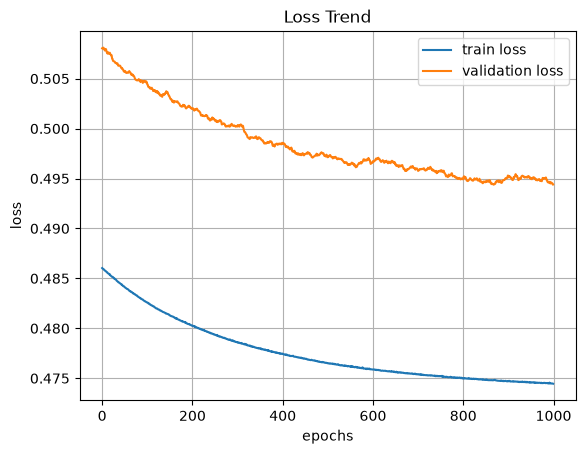

In [16]:
import matplotlib.pyplot as plt

plt.title('Loss Trend')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.grid()
plt.plot(hist.history['loss'], label='train loss')
plt.plot(hist.history['val_loss'], label='validation loss')
plt.legend(loc='best')
plt.show()

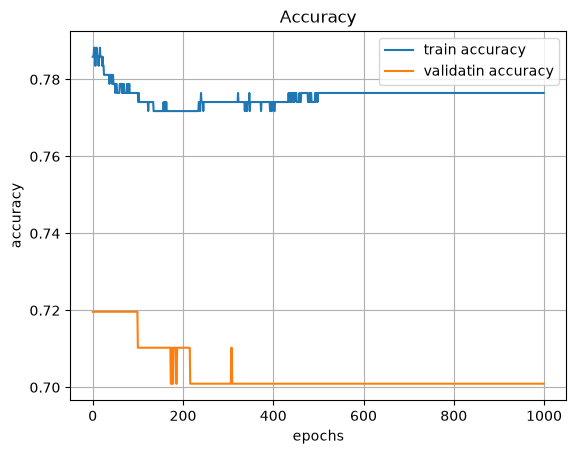

In [17]:
import matplotlib.pyplot as plt

plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.grid()
plt.plot(hist.history['accuracy'], label='train accuracy')
plt.plot(hist.history['val_accuracy'], label='validatin accuracy')
plt.legend(loc='best')
plt.show()